# B2 – Le jeu de la vie

**Python numérique – sujet bonus n° 2 – à rendre, si le cœur vous en dit, pour le vendredi 2 octobre 2026, 18 h** (en même temps que le D3)

Vous avez trouvé le second niveau caché : toutes les armes, toutes les clés, bienvenue ! Comme le premier, ce sujet n'est pas un devoir : il s'adresse à ceux qui ont de l'avance après la séance 2 et qui veulent un vrai morceau à se mettre sous la dent. Rien n'est obligatoire ; en revanche, un rendu complet donne un bonus sur votre contrôle continu, selon la règle habituelle des TP optionnels : il ne peut que faire monter la note.

Le *jeu de la vie* a été imaginé par le mathématicien John Conway en 1970 : une grille de cellules vivantes ou mortes, trois règles simples, et des comportements d'une richesse inépuisable, au point qu'on peut y construire un ordinateur. C'est un *automate cellulaire*, et c'est surtout, pour nous, le terrain de jeu idéal de la séance 2 : tout ce que nous allons faire (compter des voisins, appliquer des règles, suivre une population, essayer 256 automates à la fois) se vectorise, avec des décalages de tableaux, des masques, des agrégations sur un axe et du broadcasting. Nous commencerons par les automates à une dimension, plus simples, avant de passer à la grille.

Durée indicative : 2 h 30, davantage si vous vous prenez au jeu.

````{admonition} Consignes de rendu
:class: important

* Ce notebook reste dans le dossier `B2/` de votre dépôt `pe-homework` (celui que le zip du sujet a créé en se dézippant), avec ses figures à côté, puis il doit être **commité et poussé** (`git add`, `git commit`, `git push`) avant la date indiquée. Attention, c'est la **date du commit** qui fait foi, pas celle du push ; le nom du fichier, lui, n'a pas d'importance (`sujet.ipynb` convient très bien).
* Juste avant de rendre, **pensez à ré-exécuter toutes les cellules** via *Kernel → Restart Kernel and Run All Cells* : toutes doivent s'exécuter dans l'ordre et sans erreur.
* Les images demandées (`regle30.png`, `population.png`, `vie.png`, et `regles.png` pour le bonus) sont à enregistrer dans le dossier du notebook, et doivent aussi apparaître dans le notebook.
* Les cellules `# votre code` sont à compléter ; vous pouvez ajouter autant de cellules que vous le souhaitez. Les cellules de test (`assert`) sont là pour vous aider : si elles passent sans erreur, c'est bon signe. Ne les modifiez pas !
* Répondez aux questions "en français" dans une cellule *Markdown*, en deux ou trois phrases.
````

````{admonition} Ce qui est autorisé
:class: note

* La documentation de `numpy` / `matplotlib`, les notebooks du cours, vos notes, votre D2.
* Les assistants IA sont tolérés, avec la règle habituelle : **vous devez être capable d'expliquer chaque ligne que vous rendez**, et je pourrai vous demander de le faire à l'oral en séance. Le travail est individuel.
* Les boucles Python sur les cases d'un tableau sont interdites : compter les voisins, appliquer les règles, mesurer une population, tout se fait par opérations globales. Deux boucles sont autorisées, parce qu'elles sont inévitables : celle sur le temps (chaque génération dépend de la précédente) et celle sur les huit directions de voisinage (huit décalages, pas huit mille cases). L'exercice 4 vous fera d'ailleurs mesurer ce que coûte la boucle sur les cases.
````

````{admonition} Si vous êtes coincé
:class: tip

Ce sujet est plus long et plus ouvert qu'un devoir, et il est normal d'y buter. Si vous êtes bloqué sur une question, même en dehors des séances, écrivez-moi : [aurelien.noce@minesparis.psl.eu](mailto:aurelien.noce@minesparis.psl.eu). Dites-moi où vous en êtes et ce que vous avez essayé, je vous donne un coup de pouce, pas la réponse.
````

## Barème

| Exercice | Contenu | Points |
|---|---|---|
| 1 | Les automates à une dimension | 5 |
| 2 | Le jeu de la vie | 6 |
| 3 | Motifs et périodes | 4 |
| 4 | Boucles contre vectorisation | 3 |
| – | Notebook propre : exécuté sans erreur, réponses rédigées, figures titrées | 2 |
| **Total** | | **20** |
| Bonus | Les 256 règles d'un coup | +2 |

Le total sur 20 n'est là que pour vous situer : c'est lui qui est converti en bonus.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Exercice 1 – Les automates à une dimension (5 pts)

Avant de voisiner sur une grille, commençons plus simple : une seule *ligne* de cases valant 0 ou 1. Un automate cellulaire élémentaire fait évoluer cette ligne génération après génération, et chaque case prend une nouvelle valeur qui ne dépend que d'elle-même et de ses deux voisines immédiates, c-à-d. du triplet `(gauche, centre, droite)`. Il y a $2^3 = 8$ triplets possibles ; une *règle* est donc un choix de sortie (0 ou 1) pour chacun des huit, soit $2^8 = 256$ règles, que Stephen Wolfram a numérotées de 0 à 255.

Le codage est direct : on lit le triplet comme un nombre binaire, `indice = 4 * gauche + 2 * centre + droite` (entre 0 et 7), et le bit numéro `indice` du numéro de la règle donne la nouvelle valeur de la case. Ainsi, pour la règle 110, dont l'écriture binaire est `01101110`, le triplet `(0, 1, 0)`, d'indice 2, donne le bit 2 en partant de la droite, c-à-d. 1. Les bords sont *cycliques* : la voisine de gauche de la première case est la dernière case, et réciproquement.

Deux outils que vous n'avez pas encore vus permettent d'écrire tout cela sans boucle :

````{admonition} Pas encore vu en cours : np.roll
:class: note

`np.roll(tab, 1)` décale tous les éléments d'une case vers la droite, et ce qui sort par un bord rentre par l'autre : `np.roll(np.array([1, 2, 3, 4]), 1)` vaut `[4, 1, 2, 3]`, et `np.roll(..., -1)` décale vers la gauche. Le résultat est un nouveau tableau (une copie, pas une vue). Sur un tableau à plusieurs dimensions, on précise l'axe, et même plusieurs à la fois : `np.roll(grille, (1, -1), axis=(0, 1))` décale d'une ligne vers le bas et d'une colonne vers la gauche, d'un coup. En clair, `np.roll(ligne, 1)[i]` vaut `ligne[i - 1]` : c'est la voisine de gauche de chaque case, toutes en même temps, bords cycliques compris.
````

````{admonition} Pas encore vu en cours : les opérations bit à bit sur un tableau
:class: note

Les opérateurs `>>` (décalage de bits vers la droite) et `&` (« et » bit à bit) fonctionnent sur les entiers Python comme sur les tableaux d'entiers, case par case. Pour lire le bit numéro `k` d'un entier `n` (le bit 0 étant celui de droite), on décale puis on masque : `(n >> k) & 1`. Et si `k` est un tableau, l'expression `(n >> k) & 1` renvoie un tableau de 0 et de 1, avec le bit demandé pour chaque case : `(110 >> np.array([0, 1, 2, 3])) & 1` vaut `[0, 1, 1, 1]`. C'est du broadcasting, l'entier `n` étant "étiré" à la forme de `k`.
````

**1.a** Écrivez `etape_1d(ligne, regle)` qui renvoie la génération suivante de `ligne` (un tableau de 0 et de 1, de type `uint8`) selon la règle de numéro `regle`. Trois lignes suffisent : les deux voisines par `np.roll`, l'indice, le bit. Veillez à renvoyer un tableau `uint8` de même taille.

In [2]:
# votre code
def etape_1d(ligne, regle):
    gauche, droite = np.roll(ligne, 1), np.roll(ligne, -1)
    indice = 4*gauche + 2*ligne + droite
    return ((regle >> indice) & 1).astype(np.uint8)

In [3]:
depart = np.array([0, 0, 1, 0, 0], dtype=np.uint8)
suivante = etape_1d(depart, 110)
assert suivante.shape == (5,) and suivante.dtype == np.uint8
assert np.array_equal(suivante, [0, 1, 1, 0, 0]), "règle 110 : la case et sa voisine de gauche s'allument"
assert np.array_equal(etape_1d(np.array([0, 1, 0, 1, 0], dtype=np.uint8), 0), [0, 0, 0, 0, 0]), "la règle 0 éteint tout"
assert np.array_equal(etape_1d(np.array([1, 0, 1, 0, 1], dtype=np.uint8), 255), [1, 1, 1, 1, 1]), "la règle 255 allume tout"
assert np.array_equal(etape_1d(np.array([1, 0, 0, 0], dtype=np.uint8), 30), [1, 1, 0, 1]), "bords cycliques : la dernière case est la voisine de gauche de la première"
assert np.array_equal(depart, [0, 0, 1, 0, 0]), "la ligne reçue ne doit pas être modifiée"
print("ok")

ok


**1.b** Écrivez `simuler_1d(ligne, regle, T)` qui renvoie un tableau `(T + 1, N)` de type `uint8`, le *diagramme espace-temps* de l'automate : la ligne 0 est l'état initial, la ligne `t` est la génération `t`. C'est la boucle sur le temps, autorisée ; mais ne construisez pas une liste de lignes pour la convertir à la fin, allouez plutôt le tableau complet avec `np.zeros` et remplissez-le ligne par ligne. Pourquoi est-ce préférable ?

In [4]:
# votre code
def simuler_1d(ligne, regle, T):
    N = ligne.shape[0]
    diag = np.zeros((T+1, N), dtype=np.uint8)
    diag[0] = ligne
    for t in range(1, T+1):
        diag[t] = etape_1d(diag[t-1], regle)
    return diag

In [5]:
N = 101
graine = np.zeros(N, dtype=np.uint8)
graine[N // 2] = 1
diag90 = simuler_1d(graine, 90, 32)
assert diag90.shape == (33, 101) and diag90.dtype == np.uint8
assert np.array_equal(diag90[0], graine)
assert np.array_equal(diag90.sum(axis=1)[:9], [1, 2, 2, 4, 2, 4, 4, 8, 2]), "règle 90 : le nombre de cases allumées suit les puissances de 2"
diag30 = simuler_1d(graine, 30, 32)
assert np.array_equal(diag30[1, N // 2 - 2 : N // 2 + 3], [0, 1, 1, 1, 0])
assert diag30.sum() == 598
print("ok")

ok


Il est préférable de remplir ligne par ligne le tableau complet de np.zeros afin de ne pas garder en mémoire une grande quantité de tableaux.

**1.c** Affichez les diagrammes des règles 30, 90 et 110 sur 200 générations, à partir d'une ligne de 401 cases dont seule celle du milieu est allumée, avec `plt.imshow(diag, cmap="binary", interpolation="nearest")` (le temps descend, comme dans le tableau). Une figure par règle, avec un titre. Enregistrez celui de la règle 30 dans `regle30.png` avec `plt.imsave(..., cmap="binary")`. Que reconnaissez-vous dans la règle 90 ? Et que vous inspire la règle 30, sachant qu'elle a servi de générateur de nombres pseudo-aléatoires ?

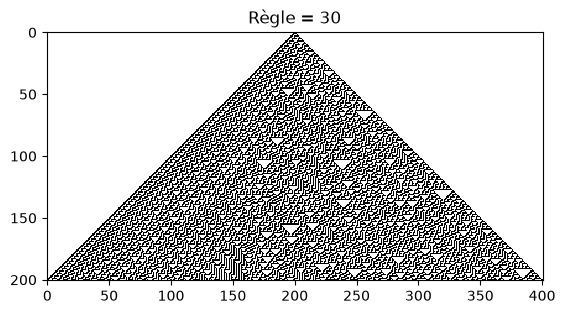

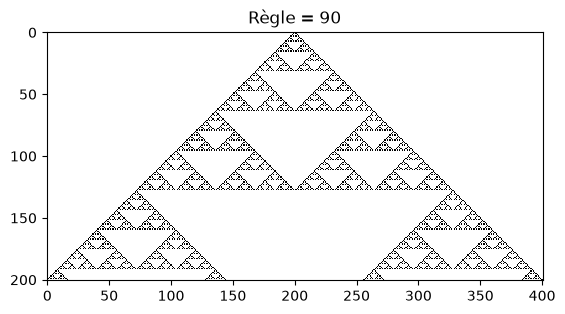

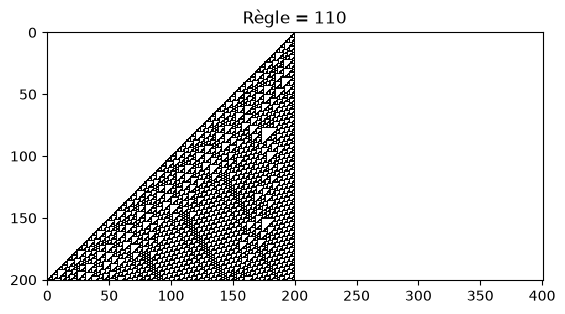

In [6]:
# votre code
graine = np.zeros(401, dtype=np.uint8)
graine[200] = 1

diag30 = simuler_1d(graine, 30, 200)
diag90 = simuler_1d(graine, 90, 200)
diag110 = simuler_1d(graine, 110, 200)

plt.title("Règle = 30")
plt.imshow(diag30, cmap="binary", interpolation="nearest")
plt.show()
plt.imsave("regle30.png", diag30, cmap="binary")

plt.title("Règle = 90")
plt.imshow(diag90, cmap="binary", interpolation="nearest")
plt.show()

plt.title("Règle = 110")
plt.imshow(diag110, cmap="binary", interpolation="nearest")
plt.show()

In [7]:
import os
assert os.path.exists("regle30.png")
print("ok")

ok


On reconnaît pour la règle 90 le triangle de Sierpiński (avec des motifs fractaux). Pour la règle 30, il semblerait que les motifs soient dispersés de manière aléatoire (on ne retrouve pas de répétition de triangle), ce qui pourrait justifier son utilisation pour la génération de nombres pseudo-aléatoires.

## Exercice 2 – Le jeu de la vie (6 pts)

Passons à deux dimensions. La grille est un tableau booléen `(H, W)` : `True` pour une cellule vivante. Chaque cellule a huit voisines (les cases adjacentes, diagonales comprises), et la grille est *torique* : elle boucle sur ses bords, exactement comme `np.roll`. À chaque génération, et simultanément pour toute la grille :

* une cellule vivante avec 2 ou 3 voisines vivantes survit ;
* une cellule morte avec exactement 3 voisines vivantes naît ;
* toute autre cellule meurt, ou reste morte.

**2.a** Écrivez `nb_voisins(grille)` qui renvoie un tableau d'entiers de même forme que la grille, où chaque case contient le nombre de voisines vivantes de la cellule correspondante. L'astuce est de ne pas raisonner case par case, mais *décalage par décalage* : la grille décalée d'une case vers le bas, lue en `(i, j)`, donne la voisine du haut de `(i, j)` ; en additionnant les huit grilles décalées (`np.roll` avec `axis=(0, 1)`), on obtient le compte de toutes les cases d'un coup. La boucle sur les huit décalages est autorisée. Attention au type : une somme de booléens doit se faire en entiers, sinon `True + True` reste… `True`.

In [10]:
# votre code
def nb_voisins(grille):
    nb_voisins = np.zeros(grille.shape, dtype=int)
    for tup in [(1, 0), (1, 1), (0, 1), (-1, 1), (-1, 0), (-1, -1), (0, -1), (1, -1)]:
        nb_voisins += np.roll(grille, tup, axis=(0, 1))
    return nb_voisins

In [11]:
seule = np.zeros((5, 5), dtype=bool)
seule[2, 2] = True
v = nb_voisins(seule)
assert v.shape == (5, 5) and v.dtype.kind == "i", "un tableau d'entiers"
assert v[2, 2] == 0, "une cellule ne se compte pas elle-même"
assert v[1, 1] == 1 and v[1, 2] == 1 and v[3, 3] == 1
assert v.sum() == 8, "une seule cellule vivante : huit cases la voient"

coin = np.zeros((6, 7), dtype=bool)
coin[0, 0] = True
v = nb_voisins(coin)
assert v[5, 6] == 1 and v[0, 6] == 1 and v[5, 0] == 1, "la grille est un tore : le coin a des voisines de l'autre côté"
assert v.sum() == 8

pleine = np.ones((4, 4), dtype=bool)
assert np.all(nb_voisins(pleine) == 8)
print("ok")

ok


**2.b** Écrivez `etape(grille)` qui renvoie la grille de la génération suivante, un tableau booléen de même forme, sans modifier celle reçue. Les trois règles tiennent en une seule expression sur des masques : « exactement 3 voisines », ou bien « vivante et exactement 2 voisines ». Rappelez-vous que `&` et `|` combinent des masques case par case, et que les comparaisons ont besoin de parenthèses autour d'elles.

In [21]:
# votre code
def etape(grille):
    generation_suiv = np.zeros(grille.shape, dtype=bool)
    voisins = nb_voisins(grille)
    masque = (grille & (voisins == 2)) | (voisins == 3)
    generation_suiv[masque] = True
    return generation_suiv

In [22]:
# le clignotant (blinker) : trois cellules alignées, qui basculent entre horizontal et vertical
g = np.zeros((7, 7), dtype=bool)
g[3, 2:5] = True
avant = g.copy()
suivante = etape(g)
assert suivante.dtype == bool and suivante.shape == (7, 7)
attendu = np.zeros((7, 7), dtype=bool)
attendu[2:5, 3] = True
assert np.array_equal(suivante, attendu), "le clignotant horizontal devient vertical"
assert np.array_equal(etape(suivante), avant), "et redevient horizontal"
assert np.array_equal(g, avant), "etape ne doit pas modifier la grille reçue"

# le bloc 2×2 est stable, la grille vide reste vide
bloc = np.zeros((6, 6), dtype=bool)
bloc[2:4, 2:4] = True
assert np.array_equal(etape(bloc), bloc)
assert not etape(np.zeros((5, 5), dtype=bool)).any()
print("ok")

ok


**2.c** Écrivez `simuler(grille, T)` qui renvoie un tableau booléen `(T + 1, H, W)` avec la grille initiale puis les `T` générations suivantes, alloué d'un coup comme à l'exercice 1.

Ensuite, fabriquez une *soupe* : une grille `64 × 64` où chaque cellule est vivante avec probabilité 0,3, tirée avec `np.random.default_rng(0)` (la graine fixe les tirages, donc les tests). Simulez 200 générations, puis calculez `population`, le nombre de cellules vivantes à chaque génération, **sans boucle** : une seule agrégation sur les deux axes d'espace suffit. Tracez la population en fonction du temps avec `plt.plot`, titre et axes nommés, et enregistrez la figure dans `population.png`. Que se passe-t-il, et pourquoi la population ne tombe-t-elle pas à zéro ?

````{admonition} Pas encore vu en cours : np.random.default_rng
:class: note

C'est la façon moderne de tirer des nombres au hasard avec `numpy` : `rng = np.random.default_rng(0)` fabrique un générateur, puis `rng.random((5, 2))` tire un tableau `(5, 2)` de flottants entre 0 et 1. La graine passée à `default_rng` rend la suite reproductible : deux exécutions donnent exactement les mêmes tirages, ce qui est bien pratique pour retrouver un bug… et pour vous corriger ! Un masque `rng.random((H, W)) < 0.3` est alors vrai dans 30 % des cases environ.
````

````{admonition} Pas encore vu en cours : agréger sur plusieurs axes à la fois
:class: note

`axis=` accepte un tuple d'axes : sur un tableau `(T, H, W)`, `tab.sum(axis=(1, 2))` additionne toutes les cases de chaque grille et renvoie un tableau `(T,)`, un total par instant. La règle reste la même qu'en séance 2 : les axes qu'on donne sont ceux qui disparaissent.
````

````{admonition} Pas encore vu en cours : habiller et enregistrer une figure
:class: note

Autour d'un `plt.plot(x, y)`, on ajoute `plt.title("…")`, `plt.xlabel("…")` et `plt.ylabel("…")`. Enfin, `plt.savefig("fig.png", dpi=120)` enregistre la figure dans un fichier ; faites-le **avant** `plt.show()`, car celui-ci referme la figure et l'on obtiendrait sinon un fichier vide. Nous verrons `matplotlib` en détail en séance 5.
````

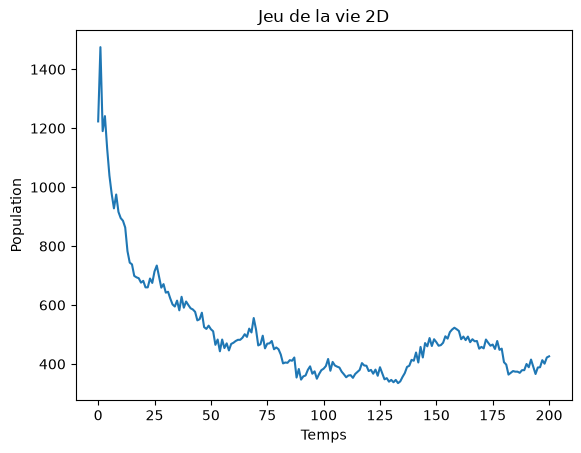

In [45]:
# votre code
def simuler(grille, T):
    H, W = grille.shape
    simulation = np.empty((T+1, H, W), dtype=bool)
    simulation[0] = grille
    for t in range(1, T+1):
        simulation[t] = etape(simulation[t-1])
    return simulation

rng = np.random.default_rng(0)
soupe = rng.random((64, 64)) < 0.3

etats = simuler(soupe, 200)

population = etats.sum(axis=(1, 2))

plt.plot(np.arange(201), population)
plt.xlabel("Temps")
plt.ylabel("Population")
plt.title("Jeu de la vie 2D")
plt.savefig("population.png", dpi=120)
plt.show()

In [46]:
assert etats.shape == (201, 64, 64) and etats.dtype == bool
assert np.array_equal(etats[0], soupe)
assert population.shape == (201,)
assert population[0] == soupe.sum() == 1223, "avec la graine 0, la soupe compte 1223 cellules vivantes"
assert population[1] == etats[1].sum()
assert population[-1] < population[0] / 2, "la population doit avoir nettement baissé"
assert population[-1] > 0
assert os.path.exists("population.png")
print("ok")

ok


On observe que la population ne tombe effectivement pas à 0 : ceci peut s'expliquer par la formation d'assemblages de cellules ne s'éteignant jamais au cours du temps (comme des blocs 2x2 par exemple, ou d'autres structures potentiellement plus complexes).

## Exercice 3 – Motifs et périodes (4 pts)

Les motifs célèbres du jeu de la vie s'écrivent commodément en texte, `#` pour une cellule vivante et `.` pour une morte :

In [49]:
MOTIFS = {
    "bloc": """
##
##
""",
    "clignotant": """
###
""",
    "crapaud": """
.###
###.
""",
    "balise": """
##..
##..
..##
..##
""",
    "planeur": """
.#.
..#
###
""",
    "pulsar": """
..###...###..
.............
#....#.#....#
#....#.#....#
#....#.#....#
..###...###..
.............
..###...###..
#....#.#....#
#....#.#....#
#....#.#....#
.............
..###...###..
""",
    "r-pentomino": """
.##
##.
.#.
""",
}

**3.a** Écrivez `lire_motif(texte)` qui renvoie le tableau booléen du motif (même recette qu'au B1 pour ceux qui l'ont fait : `np.array([list(ligne) for ligne in lignes])`, puis une comparaison), et `placer(grille, motif, i, j)` qui renvoie une **copie** de `grille` dans laquelle le motif est posé avec son coin haut-gauche en `(i, j)`. Un slicing et une affectation, rien de plus.

In [52]:
# votre code
def lire_motif(texte):
    lignes = texte.strip("\n").split("\n")
    grille = np.array([list(ligne) for ligne in lignes])
    return grille == "#"

def placer(grille, motif, i, j):
    nv_grille = grille.copy()
    h, w = motif.shape
    nv_grille[i:i+h, j:j+w] = motif
    return nv_grille

In [53]:
planeur = lire_motif(MOTIFS["planeur"])
assert planeur.shape == (3, 3) and planeur.dtype == bool
assert planeur.sum() == 5 and planeur[0, 1] and planeur[1, 2] and planeur[2].all()
assert lire_motif(MOTIFS["pulsar"]).shape == (13, 13) and lire_motif(MOTIFS["pulsar"]).sum() == 48

vide = np.zeros((16, 16), dtype=bool)
g = placer(vide, planeur, 1, 1)
assert g.shape == (16, 16) and g.sum() == 5 and g[1, 2] and g[3, 1:4].all()
assert not vide.any(), "placer renvoie une copie, la grille reçue reste vide"
print("ok")

ok


**3.b** Un *oscillateur* est un motif qui revient à son état initial après un certain nombre de générations, sa *période*. Écrivez `periode(grille, T_max=100)` qui simule `T_max` générations et renvoie la plus petite période `t > 0` telle que la génération `t` soit identique à la génération 0, ou `None` s'il n'y en a pas. Sans boucle sur les générations, s'il vous plaît : comparez d'un coup toutes les générations à la première (`etats[1:] == etats[0]` est un tableau booléen `(T_max, H, W)`, grâce au broadcasting), réduisez sur les axes d'espace pour savoir quelles générations sont *entièrement* égales, puis trouvez la première. `np.argmax` d'un tableau booléen renvoie l'indice du premier `True` ; pensez à vérifier qu'il y en a au moins un.

In [80]:
# votre code
def periode(grille, T_max=100):
    etats = simuler(grille, T_max)
    comp = np.all((etats[1:] == etats[0]), axis=(1, 2))
    if np.any(comp):
        return np.argmax(comp) + 1

In [81]:
def sur_grille(nom, taille=20, i=3, j=3):
    return placer(np.zeros((taille, taille), dtype=bool), lire_motif(MOTIFS[nom]), i, j)

assert periode(sur_grille("bloc")) == 1, "le bloc est une nature morte : période 1"
assert periode(sur_grille("clignotant")) == 2
assert periode(sur_grille("crapaud")) == 2
assert periode(sur_grille("balise")) == 2
assert periode(sur_grille("pulsar")) == 3
assert periode(sur_grille("planeur", taille=16, i=1, j=1), T_max=50) is None, "le planeur n'est pas un oscillateur"
assert periode(sur_grille("planeur", taille=16, i=1, j=1), T_max=100) == 64, "… sauf sur un tore, où il finit par revenir à son point de départ"
print("ok")

ok


**3.c** Le planeur, justement, se déplace. Vérifiez, avec `simuler` et `np.roll`, qu'après 4 générations un planeur posé sur une grille `16 × 16` est exactement la grille initiale décalée d'une case, et dites dans quelle direction (vers quel coin) il avance. Expliquez au passage pourquoi la période sur le tore vaut 64.

Enfin, posez le *r-pentomino* au centre d'une grille `64 × 64`, simulez 200 générations, et affichez la génération 200 avec `plt.imshow(..., cmap="binary")` ; enregistrez-la dans `vie.png` avec `plt.imsave`. Cinq cellules au départ : combien à l'arrivée ?

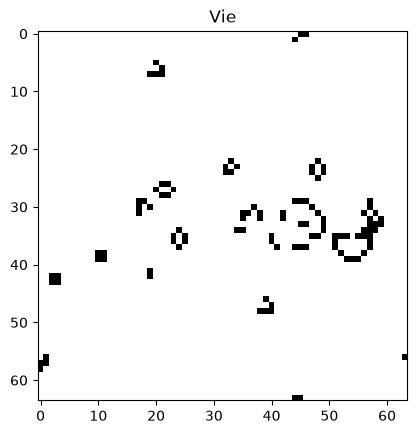

In [100]:
# votre code
vide = np.zeros((16, 16), dtype=bool)
grille = placer(vide, lire_motif(MOTIFS["planeur"]), 1, 1)

assert np.array_equal(np.roll(grille, 1, axis=(0, 1)), simuler(grille, 4)[-1])

grille2 = placer(np.zeros((64, 64), dtype=bool), lire_motif(MOTIFS["r-pentomino"]), 31, 31)
sim = simuler(grille2, 200)
final = sim[-1]

plt.title("Vie")
plt.imshow(final, cmap="binary")
plt.show()
plt.imsave("vie.png", final)

In [101]:
assert os.path.exists("vie.png")
assert np.array_equal(simuler(sur_grille("planeur", taille=16, i=1, j=1), 4)[4],
                      np.roll(sur_grille("planeur", taille=16, i=1, j=1), (1, 1), axis=(0, 1)))
print("ok")

ok


Pour la première partie, le planeur avance vers le coin sud-est.

In [104]:
print("Il y a " + str(np.sum(final)) + " cellules à l'arrivée pour le r-pentomino.")

Il y a 113 cellules à l'arrivée pour le r-pentomino.


## Exercice 4 – Boucles contre vectorisation (3 pts)

Voici, pour comparaison, la même génération écrite comme on l'écrirait sans `numpy`, avec une boucle sur chaque case et une boucle sur chaque voisine, et le modulo pour le tore :

In [105]:
def etape_boucles(grille):
    H, W = grille.shape
    suivante = np.zeros_like(grille)
    for i in range(H):
        for j in range(W):
            n = 0
            for di in (-1, 0, 1):
                for dj in (-1, 0, 1):
                    if di != 0 or dj != 0:
                        n += grille[(i + di) % H, (j + dj) % W]
            suivante[i, j] = (n == 3) or (grille[i, j] and n == 2)
    return suivante

**4.a** Vérifiez sur une soupe `64 × 64` (graine 1) que `etape_boucles` et votre `etape` donnent exactement la même grille. Puis mesurez le temps de chacune avec `%timeit` (comme au point d'arrêt de la séance 1), et notez le rapport dans une cellule Markdown. D'où vient un tel écart, alors que les deux versions font, au fond, les mêmes additions ? Que deviendrait-il sur une grille `1024 × 1024` ?

In [109]:
# votre code
rng1 = np.random.default_rng(1)
soupe1 = rng1.random((64, 64)) < 0.3

assert np.array_equal(etape_boucles(soupe1), etape(soupe1))

%timeit etape_boucles(soupe1)
%timeit etape(soupe1)     # Bien plus rapide : on gagne 100 fois plus de temps en ordre de grandeur

23.2 ms ± 557 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
208 μs ± 4.65 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


L'équart provient de la différence de temps entre les boucles python et les fonctions numpy, exécutées en C et donc plus rapides.

In [114]:
rng2 = np.random.default_rng(2)
soupe2 = rng2.random((1024, 1024)) < 0.3

%timeit etape_boucles(soupe2) # 6 s
%timeit etape(soupe2) # 28 ms -> même ordre de grandeur de différence

6.14 s ± 50.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
28.2 ms ± 1.51 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [113]:
soupe1 = np.random.default_rng(1).random((64, 64)) < 0.3
assert np.array_equal(etape_boucles(soupe1), etape(soupe1))
print("ok")

ok


## Bonus (+2) – Les 256 règles d'un coup

À l'exercice 1, chaque règle demandait sa propre simulation. Or rien, dans `etape_1d`, ne dépend vraiment du fait que `regle` soit un seul entier : si `regle` est un tableau `(256, 1)` et `indice` un tableau `(256, N)` (256 lignes, une par règle), l'expression `(regle >> indice) & 1` calcule d'un coup, par broadcasting, la génération suivante des 256 automates.

**B.1** Écrivez `toutes_les_regles(ligne, T)` qui renvoie un tableau `(256, T + 1, N)` de type `uint8` : le diagramme espace-temps de chacune des 256 règles à partir de la même ligne initiale. Seule la boucle sur le temps est autorisée ; à chaque pas, vous traitez les 256 règles ensemble (les décalages se font le long de l'axe des cases, `axis=1`, sur un tableau `(256, N)`).

**B.2** Assemblez les 256 diagrammes en une seule image, une *mosaïque* de 16 lignes et 16 colonnes de diagrammes (la règle `r` en ligne `r // 16`, colonne `r % 16`), de forme `(16 * (T + 1), 16 * N)`. Pas de boucle, pas de `concatenate` : c'est un pur exercice de `reshape` et de `transpose`. Affichez-la avec `cmap="binary"` et enregistrez-la dans `regles.png`. Prenez une ligne de 33 cases et 16 générations, pour une image lisible.

````{admonition} Pas encore vu en cours : transpose sur plus de deux axes
:class: note

`tab.T` échange les deux axes d'une matrice ; sur un tableau à plus de dimensions, `tab.transpose(0, 2, 1, 3)` renvoie une vue dont les axes sont réordonnés comme indiqué (ici les axes 1 et 2 sont échangés). Un `reshape` après un `transpose` ne peut plus, en général, se contenter d'une vue : `numpy` copie alors les données, et c'est justement ce qu'on veut ici pour obtenir l'image finale.
````

In [ ]:
# votre code

In [ ]:
N, T = 33, 16
graine = np.zeros(N, dtype=np.uint8)
graine[N // 2] = 1
toutes = toutes_les_regles(graine, T)
assert toutes.shape == (256, 17, 33) and toutes.dtype == np.uint8
assert np.array_equal(toutes[90], simuler_1d(graine, 90, T)), "la règle 90 doit coïncider avec l'exercice 1"
assert np.array_equal(toutes[30], simuler_1d(graine, 30, T))
assert not toutes[0, 1:].any(), "règle 0 : tout s'éteint"
assert toutes[255, 1:].all(), "règle 255 : tout s'allume"
assert mosaique.shape == (16 * 17, 16 * 33)
assert np.array_equal(mosaique[17 * 5 : 17 * 6, 33 * 10 : 33 * 11], toutes[5 * 16 + 10]), "la règle 90 est en ligne 5, colonne 10"
assert os.path.exists("regles.png")
print("ok")

Bon courage à tous, et bonne vie ! Pour toute question sur le sujet, vous pouvez me contacter par email : [aurelien.noce@minesparis.psl.eu](mailto:aurelien.noce@minesparis.psl.eu).

Au plaisir de vous lire,

votre responsable de cours, Aurélien Noce

In [ ]:
# votre code